# Problem 5.2 – Binary Cross-Entropy Loss Visualization

We want to plot the binary classification loss for a *single* training pair \((\mathbf{x}, y)\):
\[
L(p, y) = -(1-y)\log(1-p) - y\log(p), \qquad p = \operatorname{sig}(f[\mathbf{x},\phi]) \in [0,1]
\]

We'll visualize two cases:
1. Label **y = 0**  →  loss:  \(L(p,0) = -\log(1-p)\)
2. Label **y = 1**  →  loss:  \(L(p,1) = -\log(p)\)

Key properties:
- The loss diverges as predicted probability approaches the wrong class (e.g. \(p \to 0\) when \(y=1\), or \(p \to 1\) when \(y=0\)).
- The minimum is 0 at the correct confident prediction: \(p=0\) for \(y=0\) and \(p=1\) for \(y=1\).
- This forms the standard negative log-likelihood (cross-entropy) for Bernoulli targets.

We'll clip probabilities slightly away from 0 and 1 to avoid numerical issues with \(\log(0)\).

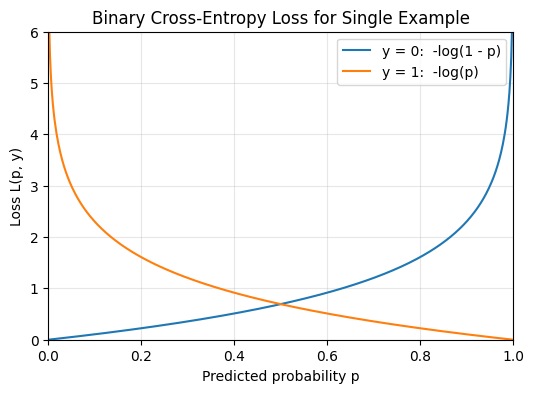

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Probability grid (avoid exact 0 or 1 to prevent log(0))
p = np.linspace(1e-6, 1-1e-6, 500)

# Loss for y = 0 and y = 1
L_y0 = -np.log(1 - p)      # when y=0
L_y1 = -np.log(p)          # when y=1

plt.figure(figsize=(6,4))
plt.plot(p, L_y0, label='y = 0:  -log(1 - p)', color='tab:blue')
plt.plot(p, L_y1, label='y = 1:  -log(p)', color='tab:orange')
plt.ylim(0, 6)  # cap for visibility; the curves shoot upward near the asymptotes
plt.xlim(0, 1)
plt.xlabel('Predicted probability p')
plt.ylabel('Loss L(p, y)')
plt.title('Binary Cross-Entropy Loss for Single Example')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
def binary_cross_entropy(p: np.ndarray, y: int):
    """Binary cross-entropy for a single label y in {0,1} and predicted prob(s) p.
    Clips p for numerical stability.
    """
    p_clipped = np.clip(p, 1e-12, 1-1e-12)
    return -(1 - y) * np.log(1 - p_clipped) - y * np.log(p_clipped)

# Quick verification at a few sample points
for y in (0, 1):
    test_p = np.array([0.01, 0.25, 0.5, 0.75, 0.99])
    direct = binary_cross_entropy(test_p, y)
    if y == 0:
        reference = -np.log(1 - test_p)
    else:
        reference = -np.log(test_p)
    print(f"y={y} match:", np.allclose(direct, reference))

binary_cross_entropy(np.array([0.2, 0.8]), 1)